In [1]:
# All dependencies are managed via the project venv.
# See README.md for setup instructions.
# Activate with: source venv/bin/activate

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    precision_score, recall_score, f1_score, average_precision_score
)
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Paths — notebook lives in notebooks/, data and models are siblings at project root
PROJECT_ROOT = os.path.dirname(os.getcwd())
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

print('Imports ready.')
print(f'Data dir:   {DATA_DIR}')
print(f'Models dir: {MODELS_DIR}')

Imports ready.
Data dir:   /Users/margarida/Documents/Fairfield University/01. MSBA/02. Spring 26/DATA 6545/Final Project/uber-cancellation-prediction/data
Models dir: /Users/margarida/Documents/Fairfield University/01. MSBA/02. Spring 26/DATA 6545/Final Project/uber-cancellation-prediction/models


/Users/margarida/Documents/Fairfield University/01. MSBA/02. Spring 26/DATA 6545/Final Project/uber-cancellation-prediction/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Inspection

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "ncr_ride_bookings.csv"))
print(f"Shape: {df.shape}")
df.head()

Shape: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [5]:
# Inspect unique values of key categorical columns
for col in ['Booking Status', 'Vehicle Type', 'Payment Method']:
    print(f"{col}: {df[col].unique()}")
    print()

Booking Status: ['No Driver Found' 'Incomplete' 'Completed' 'Cancelled by Driver'
 'Cancelled by Customer']

Vehicle Type: ['eBike' 'Go Sedan' 'Auto' 'Premier Sedan' 'Bike' 'Go Mini' 'Uber XL']

Payment Method: [nan 'UPI' 'Debit Card' 'Cash' 'Uber Wallet' 'Credit Card']



In [6]:
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

**Notes on missing values and leakage:**

The following columns are **only populated for completed or in-progress rides**
and are therefore unavailable at booking time. Using them or their missingness
flags would cause data leakage — the model would learn post-outcome signals
rather than booking-time signals.

| Column | Why excluded |
|---|---|
| `Avg CTAT` | 100% null for all cancellation statuses — only recorded after a driver is confirmed |
| `Booking Value` | 100% null on all cancelled rows — fare is only logged after ride completion |
| `Ride Distance` | Same — only known after the ride |
| `Driver Ratings` / `Customer Rating` | Only populated for Completed rides |
| `Payment Method` | Only recorded when payment occurs |
| `Cancelled Rides by Customer/Driver` | Directly encodes the outcome by cancellation type |
| `Reason for cancelling by Customer/Driver` | Post-cancellation fields |
| `Incomplete Rides` / `Incomplete Rides Reason` | Only populated for Incomplete rows |

`Avg VTAT` is retained: it is populated for all statuses **except** "No Driver Found",
meaning it reflects real-time driver matching speed before the outcome is decided.
Its missingness (only for No Driver Found rows) is itself a clean, pre-outcome signal.

## 2. Data Cleaning

In [7]:
# Strip stray quotes from ID columns
df["Booking ID"]  = df["Booking ID"].str.strip('"')
df["Customer ID"] = df["Customer ID"].str.strip('"')

# Parse datetime fields
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce").dt.time

print("Cleaning done.")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

Cleaning done.
Date range: 2024-01-01 → 2024-12-30


## 3. Target Variable

We define **Cancelled = 1** for any booking that did not complete
(Cancelled by Customer, Cancelled by Driver, No Driver Found, Incomplete).
**Cancelled = 0** for Completed rides only.

In [8]:
df['Cancelled'] = (df['Booking Status'] != 'Completed').astype(int)

print("Target distribution:")
print(df['Cancelled'].value_counts())
print()
print(df['Cancelled'].value_counts(normalize=True).round(3))

Target distribution:
Cancelled
0    93000
1    57000
Name: count, dtype: int64

Cancelled
0    0.62
1    0.38
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis

### 4.1 Booking status breakdown

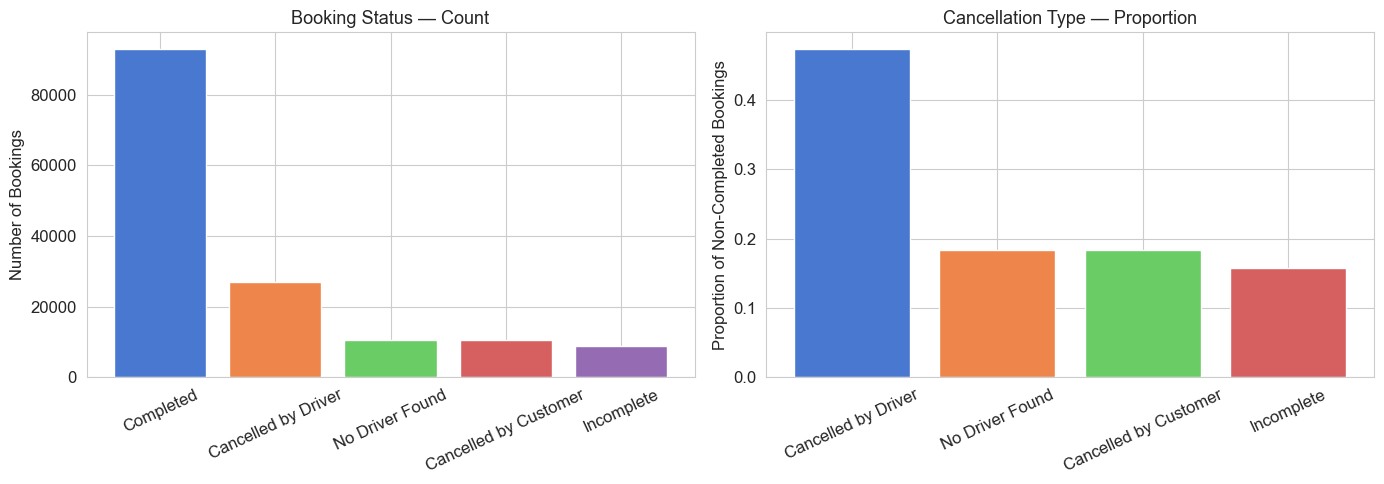

In [9]:
status_counts = df['Booking Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
axes[0].bar(status_counts.index, status_counts.values,
            color=sns.color_palette("muted", len(status_counts)))
axes[0].set_title("Booking Status — Count", fontsize=13)
axes[0].set_ylabel("Number of Bookings")
axes[0].tick_params(axis="x", rotation=25)

# Cancellation types only
df_cancel = df[df['Booking Status'] != 'Completed']
cancel_counts = df_cancel['Booking Status'].value_counts(normalize=True)
axes[1].bar(cancel_counts.index, cancel_counts.values,
            color=sns.color_palette("muted", len(cancel_counts)))
axes[1].set_title("Cancellation Type — Proportion", fontsize=13)
axes[1].set_ylabel("Proportion of Non-Completed Bookings")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### 4.2 Cancellation rate by hour of day

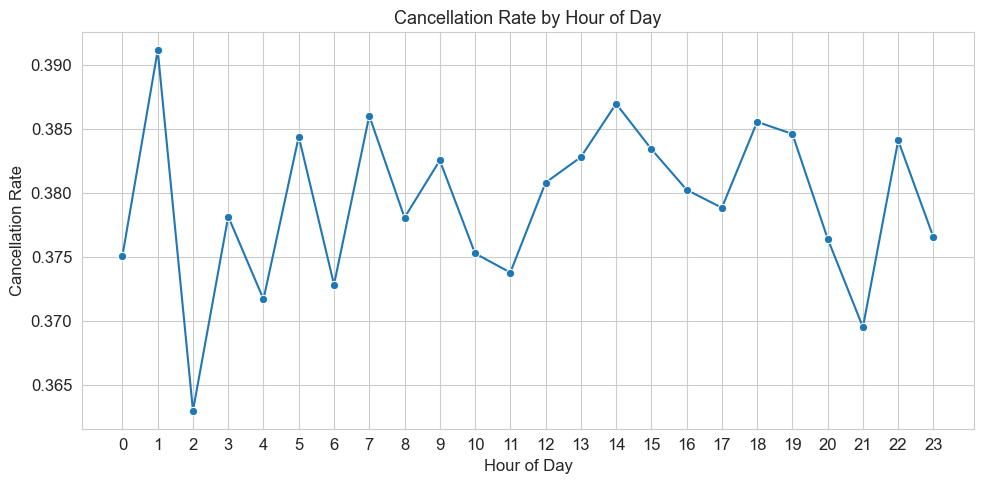

In [10]:
df["hour"] = pd.to_datetime(df["Time"].astype(str), errors="coerce").dt.hour

hourly_total  = df.groupby("hour").size()
hourly_cancel = df[df["Cancelled"] == 1].groupby("hour").size()
cancel_rate   = (hourly_cancel / hourly_total).reset_index(name="cancel_rate")

plt.figure(figsize=(10, 5))
sns.lineplot(data=cancel_rate, x="hour", y="cancel_rate", marker="o")
plt.title("Cancellation Rate by Hour of Day", fontsize=13)
plt.xlabel("Hour of Day")
plt.ylabel("Cancellation Rate")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 4.3 Cancellation rate by vehicle type

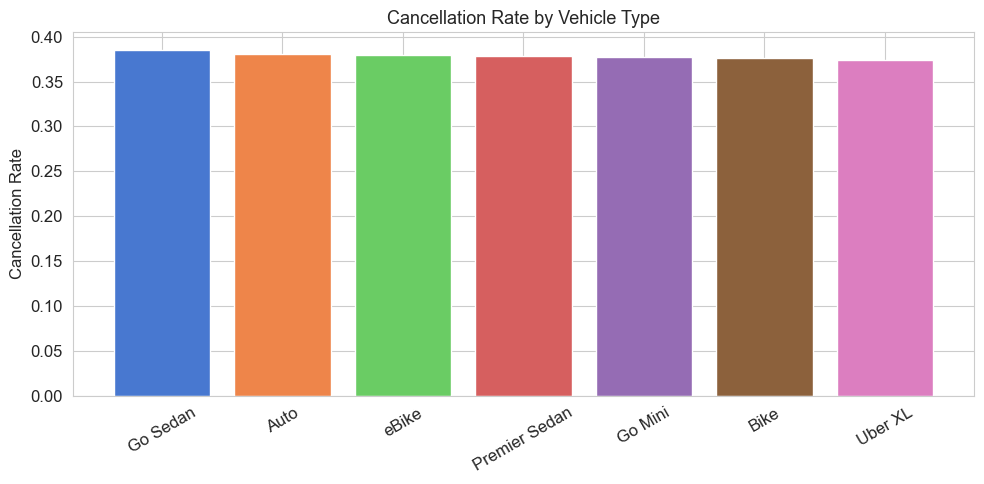

In [11]:
veh_cancel = (df.groupby("Vehicle Type")["Cancelled"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "cancel_rate", "count": "n"})
                .sort_values("cancel_rate", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(veh_cancel.index, veh_cancel["cancel_rate"],
       color=sns.color_palette("muted", len(veh_cancel)))
ax.set_title("Cancellation Rate by Vehicle Type", fontsize=13)
ax.set_ylabel("Cancellation Rate")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 4.4 Cancellation rate by top 10 pickup locations

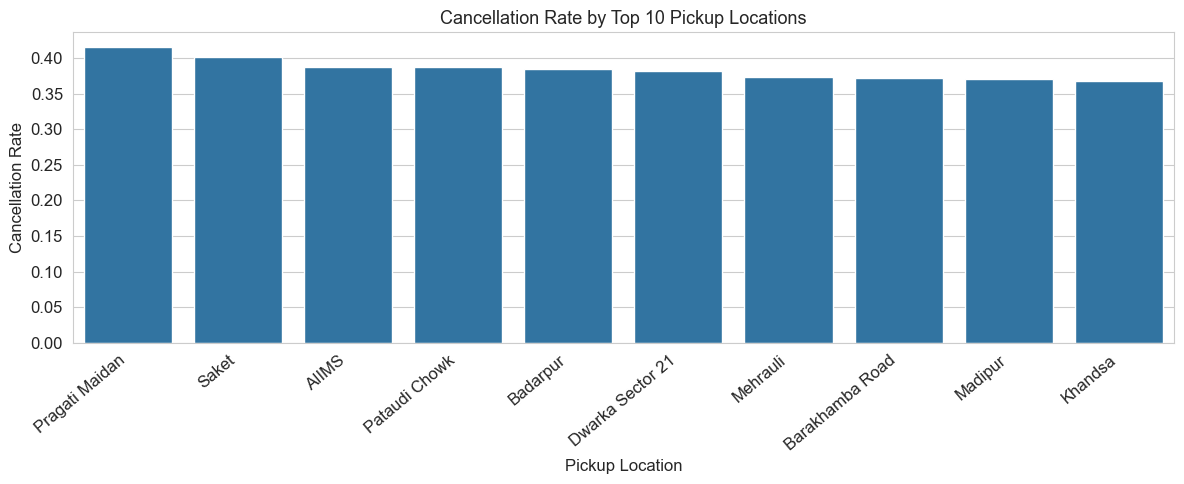

In [12]:
top_pickups    = df['Pickup Location'].value_counts().nlargest(10).index
df_top_pickups = df[df['Pickup Location'].isin(top_pickups)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_top_pickups, x='Pickup Location', y='Cancelled', errorbar=None,
            order=df_top_pickups.groupby('Pickup Location')['Cancelled']
                                .mean().sort_values(ascending=False).index)
plt.title("Cancellation Rate by Top 10 Pickup Locations", fontsize=13)
plt.xlabel("Pickup Location")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

### 4.5 Avg VTAT distribution — cancelled vs completed

`Avg VTAT` (Vendor Time to Assign) is the only numeric operational feature
available at booking time without leakage. We expect longer VTAT to correlate
with higher cancellation probability.

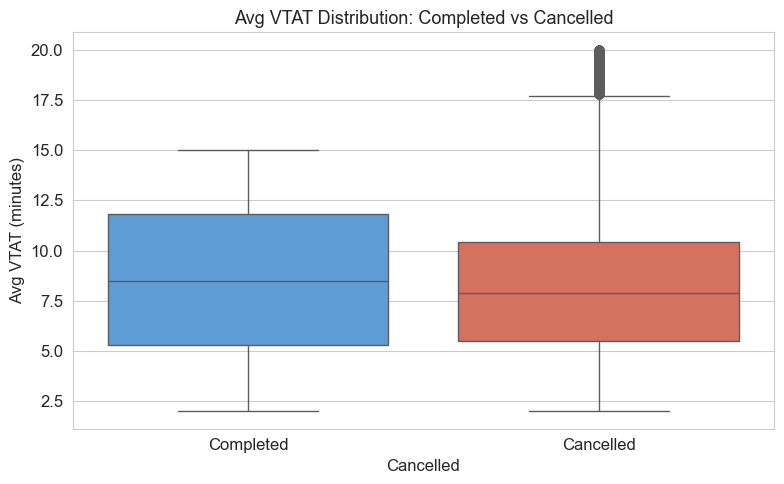

Median Avg VTAT:
Cancelled
0    8.5
1    7.9
Name: Avg VTAT, dtype: float64


In [13]:
# Exclude "No Driver Found" rows for this plot — VTAT is null there by definition
df_vtat = df[df["Booking Status"] != "No Driver Found"].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_vtat, x="Cancelled", y="Avg VTAT",
            palette=["#4C9BE8", "#E8634C"])
plt.xticks([0, 1], ["Completed", "Cancelled"])
plt.title("Avg VTAT Distribution: Completed vs Cancelled", fontsize=13)
plt.ylabel("Avg VTAT (minutes)")
plt.tight_layout()
plt.show()

print("Median Avg VTAT:")
print(df_vtat.groupby("Cancelled")["Avg VTAT"].median())

### 4.6 Cancellation rate by day of week and month

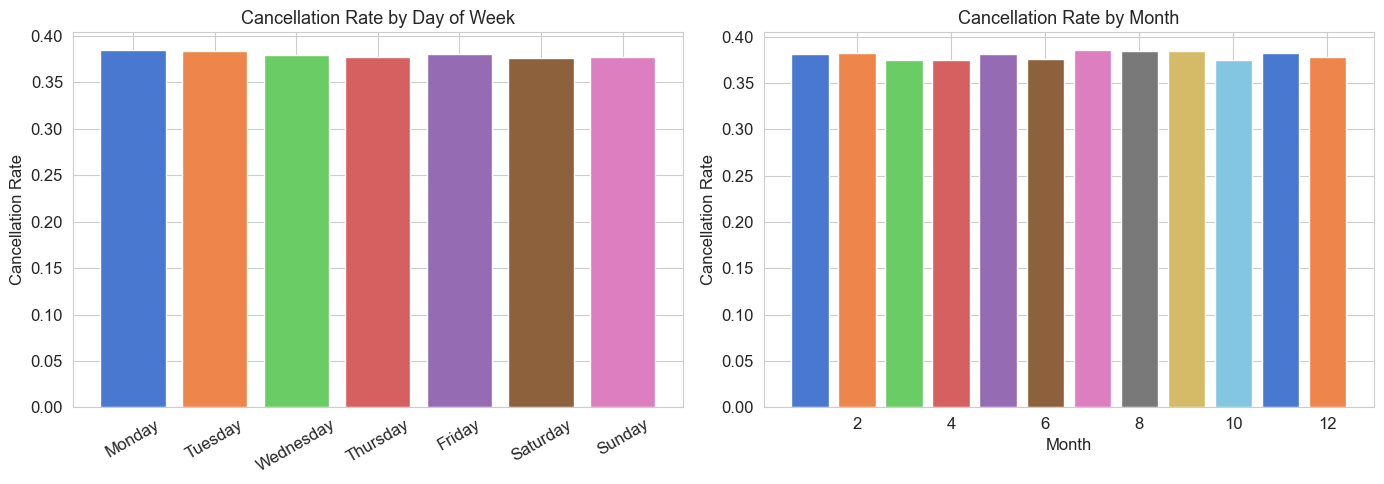

In [14]:
df["day_of_week"] = df["Date"].dt.day_name()
df["month"]       = df["Date"].dt.month

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_cancel = df.groupby("day_of_week")["Cancelled"].mean().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow_cancel.index, dow_cancel.values,
            color=sns.color_palette("muted", 7))
axes[0].set_title("Cancellation Rate by Day of Week", fontsize=13)
axes[0].set_ylabel("Cancellation Rate")
axes[0].tick_params(axis="x", rotation=30)

month_cancel = df.groupby("month")["Cancelled"].mean()
axes[1].bar(month_cancel.index, month_cancel.values,
            color=sns.color_palette("muted", 12))
axes[1].set_title("Cancellation Rate by Month", fontsize=13)
axes[1].set_ylabel("Cancellation Rate")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

## 5. Feature Engineering

**Features used — all known strictly at booking time:**

| Feature | Source | Notes |
|---|---|---|
| `hour` | Time column | Continuous hour (0–23) |
| `hour_bucket` | Derived from hour | 4 buckets: night / morning / afternoon / evening |
| `day_of_week` | Date column | Categorical |
| `month` | Date column | Cyclical demand signal |
| `is_weekend` | Date column | Binary |
| `Vehicle Type` | Raw column | Customer-selected at booking |
| `Pickup Location` (top-N) | Raw column | Top 15 locations encoded, rest → "Other" |
| `Drop Location` (top-N) | Raw column | Top 15 locations encoded, rest → "Other" |
| `Avg VTAT` | Raw column | Real-time driver assignment speed; null only for No Driver Found |
| `vtat_missing` | Derived | 1 = No Driver Found status (clean pre-outcome signal) |

**Excluded (leakage):** `Avg CTAT`, `Booking Value`, `Ride Distance`,
`Driver Ratings`, `Customer Rating`, `Payment Method`,
`Cancelled Rides by Customer/Driver`, all cancellation reason columns.

In [15]:
df_model = df.copy()

# ── Time features ──
def hour_bucket(h):
    if h < 6:    return "night"
    elif h < 12: return "morning"
    elif h < 18: return "afternoon"
    else:        return "evening"

df_model["hour_bucket"] = df_model["hour"].apply(hour_bucket)
df_model["is_weekend"]  = df_model["Date"].dt.dayofweek.isin([5, 6]).astype(int)
# month already computed in EDA

# ── VTAT missing flag (No Driver Found = no match attempted) ──
df_model["vtat_missing"] = df_model["Avg VTAT"].isna().astype(int)

# ── Location encoding: top 15 + "Other" ──
for loc_col, prefix in [("Pickup Location", "pickup"), ("Drop Location", "drop")]:
    top_locs = df_model[loc_col].value_counts().nlargest(15).index
    df_model[f"{prefix}_grouped"] = df_model[loc_col].apply(
        lambda x: x if x in top_locs else "Other"
    )

print("Feature engineering done.")
print(f"Columns added: hour_bucket, is_weekend, vtat_missing, pickup_grouped, drop_grouped")

Feature engineering done.
Columns added: hour_bucket, is_weekend, vtat_missing, pickup_grouped, drop_grouped


In [16]:
# ── Define feature lists by type ──
NUMERIC_FEATURES = ["hour", "month", "is_weekend", "vtat_missing", "Avg VTAT"]

CATEGORICAL_FEATURES = ["hour_bucket", "day_of_week", "Vehicle Type",
                         "pickup_grouped", "drop_grouped"]

TARGET = "Cancelled"

X = df_model[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_model[TARGET]

print(f"Feature matrix: {X.shape}")
print(f"  Numeric    ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"  Categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\nTarget distribution:\n{y.value_counts(normalize=True).round(3)}")

Feature matrix: (150000, 10)
  Numeric    (5): ['hour', 'month', 'is_weekend', 'vtat_missing', 'Avg VTAT']
  Categorical (5): ['hour_bucket', 'day_of_week', 'Vehicle Type', 'pickup_grouped', 'drop_grouped']

Target distribution:
Cancelled
0    0.62
1    0.38
Name: proportion, dtype: float64


## 6. Preprocessing Pipeline & Train/Test Split

We use a `ColumnTransformer` with separate sub-pipelines for numeric and
categorical features, wrapped in a single `Pipeline` with the classifier.
This ensures preprocessing is **fit only on training data inside each CV fold**,
preventing any form of data leakage from imputation or scaling.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train cancellation rate: {y_train.mean():.3f}")
print(f"Test  cancellation rate: {y_test.mean():.3f}")

Train: 120,000 rows  |  Test: 30,000 rows
Train cancellation rate: 0.380
Test  cancellation rate: 0.380


In [18]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,      NUMERIC_FEATURES),
    ("cat", categorical_pipeline,  CATEGORICAL_FEATURES)
])

print("Preprocessor defined.")

Preprocessor defined.


## 7. Baseline Model — Logistic Regression

Logistic regression with `class_weight='balanced'` is our baseline.
It is fast, interpretable, and sets the floor that tree-based models must beat.

In [19]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

print(f"{'Metric':<25} {'Baseline LR':>12}")
print("=" * 39)
print(f"{'Accuracy':<25} {pipe_lr.score(X_test, y_test):>12.3f}")
print(f"{'ROC-AUC':<25} {roc_auc_score(y_test, y_prob_lr):>12.3f}")
print(f"{'Recall (Cancelled)':<25} {recall_score(y_test, y_pred_lr):>12.3f}")
print(f"{'Precision (Cancelled)':<25} {precision_score(y_test, y_pred_lr):>12.3f}")
print(f"{'F1 (Cancelled)':<25} {f1_score(y_test, y_pred_lr):>12.3f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Completed", "Cancelled"]))

Metric                     Baseline LR
Accuracy                         0.690
ROC-AUC                          0.609
Recall (Cancelled)               0.183
Precision (Cancelled)            0.998
F1 (Cancelled)                   0.310

              precision    recall  f1-score   support

   Completed       0.67      1.00      0.80     18600
   Cancelled       1.00      0.18      0.31     11400

    accuracy                           0.69     30000
   macro avg       0.83      0.59      0.55     30000
weighted avg       0.79      0.69      0.61     30000



In [20]:
# 5-fold CV on training set — preprocessing inside each fold, no leakage
cv_scores = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring="roc_auc")
print(f"5-Fold CV ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

5-Fold CV ROC-AUC: 0.605 (+/- 0.001)


## 8. Model Comparison

We compare three classifiers — Logistic Regression, Random Forest, and
HistGradientBoosting — using the same preprocessor and pipeline structure.
`HistGradientBoostingClassifier` handles `Avg VTAT` nulls natively,
which is an advantage given our feature set.

### 8.1 Define models

In [21]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200, class_weight="balanced", random_state=42
    ),
}

### 8.2 5-fold cross-validation

In [22]:
scoring_metrics = {
    "roc_auc":   "roc_auc",
    "recall":    "recall",
    "precision": "precision",
    "f1":        "f1",
    "accuracy":  "accuracy",
}

comparison_cv = []

for name, model in models.items():
    model_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   model)
    ])
    row = {"Model": name}
    for label, scorer in scoring_metrics.items():
        scores = cross_val_score(model_pipe, X_train, y_train, cv=5, scoring=scorer)
        row[label] = f"{scores.mean():.3f} (+/- {scores.std():.3f})"
    comparison_cv.append(row)
    print(f"  {name} done.")

print("\n5-Fold CV Results:")
print(pd.DataFrame(comparison_cv).to_string(index=False))

  Logistic Regression done.
  Random Forest done.
  Gradient Boosting done.

5-Fold CV Results:
              Model           roc_auc            recall         precision                f1          accuracy
Logistic Regression 0.605 (+/- 0.001) 0.186 (+/- 0.002) 0.982 (+/- 0.008) 0.313 (+/- 0.003) 0.689 (+/- 0.001)
      Random Forest 0.688 (+/- 0.002) 0.438 (+/- 0.002) 0.583 (+/- 0.003) 0.500 (+/- 0.002) 0.668 (+/- 0.001)
  Gradient Boosting 0.723 (+/- 0.003) 0.664 (+/- 0.010) 0.511 (+/- 0.002) 0.578 (+/- 0.004) 0.631 (+/- 0.002)


### 8.3 Fit on full training set — evaluate on held-out test set

In [23]:
fitted_pipes = {}
test_results = []

for name, model in models.items():
    pipe_m = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   model)
    ])
    pipe_m.fit(X_train, y_train)
    fitted_pipes[name] = pipe_m

    y_pred = pipe_m.predict(X_test)
    y_prob = pipe_m.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model":              name,
        "Accuracy":           pipe_m.score(X_test, y_test),
        "ROC-AUC":            roc_auc_score(y_test, y_prob),
        "Recall (Canc.)":     recall_score(y_test, y_pred),
        "Precision (Canc.)":  precision_score(y_test, y_pred),
        "F1 (Canc.)":         f1_score(y_test, y_pred),
    })
    print(f"  {name} done.")

results_df = pd.DataFrame(test_results)
print("\nTest Set Results:")
print(results_df.set_index("Model").round(3).to_string())

  Logistic Regression done.
  Random Forest done.
  Gradient Boosting done.

Test Set Results:
                     Accuracy  ROC-AUC  Recall (Canc.)  Precision (Canc.)  F1 (Canc.)
Model                                                                                
Logistic Regression     0.690    0.609           0.183              0.998       0.310
Random Forest           0.665    0.687           0.448              0.577       0.504
Gradient Boosting       0.635    0.725           0.666              0.516       0.581


### 8.4 ROC curve comparison

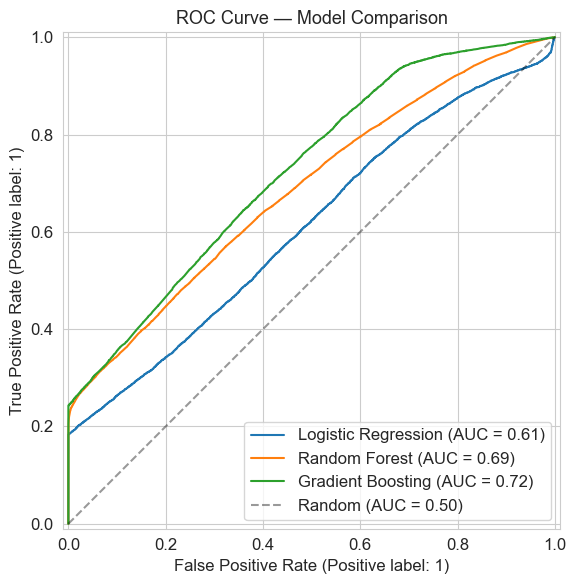

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, pipe_m in fitted_pipes.items():
    y_prob = pipe_m.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=name)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — Model Comparison", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 8.5 Confusion matrices

For this problem **false negatives (missed cancellations) are more costly**
than false positives — a missed cancellation means a driver was dispatched
for a ride that never happened.

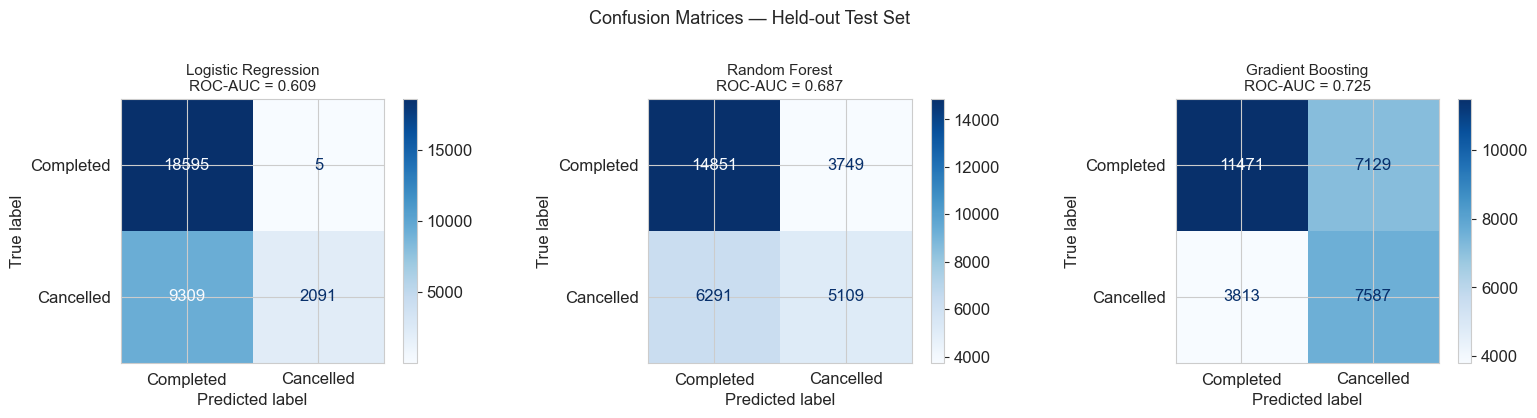

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, pipe_m) in zip(axes, fitted_pipes.items()):
    y_pred = pipe_m.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Completed", "Cancelled"],
        cmap="Blues", ax=ax
    )
    auc = roc_auc_score(y_test, pipe_m.predict_proba(X_test)[:, 1])
    ax.set_title(f"{name}\nROC-AUC = {auc:.3f}", fontsize=11)

plt.suptitle("Confusion Matrices — Held-out Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 8.6 Select best model

In [26]:
best_model_name = results_df.sort_values(
    ["ROC-AUC", "Recall (Canc.)"], ascending=False
).iloc[0]["Model"]

best_pipe = fitted_pipes[best_model_name]

row = results_df[results_df["Model"] == best_model_name].iloc[0]
print(f"Best model: {best_model_name}")
print(f"  ROC-AUC:           {row['ROC-AUC']:.3f}")
print(f"  Recall (Canc.):    {row['Recall (Canc.)']:.3f}")
print(f"  Precision (Canc.): {row['Precision (Canc.)']:.3f}")
print(f"  F1 (Canc.):        {row['F1 (Canc.)']:.3f}")

Best model: Gradient Boosting
  ROC-AUC:           0.725
  Recall (Canc.):    0.666
  Precision (Canc.): 0.516
  F1 (Canc.):        0.581


## 9. SHAP Feature Explainability

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution
to individual predictions. This is critical for a business deployment: if
the platform flags a booking as high-risk, the operations team needs to know
*why* to take the right action.
We use `TreeExplainer` on the best model (HistGradientBoosting), which is
exact and efficient for tree-based models.

### 9.1 Extract preprocessor and transform test set

In [27]:
preprocessor_fitted = best_pipe.named_steps["preprocessor"]
classifier_fitted   = best_pipe.named_steps["classifier"]

X_test_tf  = preprocessor_fitted.transform(X_test)
X_train_tf = preprocessor_fitted.transform(X_train)

# Recover readable feature names — strip ColumnTransformer prefixes
try:
    feature_names = [n.split("__", 1)[-1]
                     for n in preprocessor_fitted.get_feature_names_out()]
except Exception:
    feature_names = (NUMERIC_FEATURES +
                     list(preprocessor_fitted.named_transformers_["cat"]
                          .named_steps["encoder"].get_feature_names_out(CATEGORICAL_FEATURES)))

X_test_tf  = pd.DataFrame(X_test_tf,  columns=feature_names)
X_train_tf = pd.DataFrame(X_train_tf, columns=feature_names)

print(f"Transformed shape: {X_test_tf.shape}")
print(f"Features: {feature_names}")

Transformed shape: (30000, 55)
Features: ['hour', 'month', 'is_weekend', 'vtat_missing', 'Avg VTAT', 'hour_bucket_afternoon', 'hour_bucket_evening', 'hour_bucket_morning', 'hour_bucket_night', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'Vehicle Type_Auto', 'Vehicle Type_Bike', 'Vehicle Type_Go Mini', 'Vehicle Type_Go Sedan', 'Vehicle Type_Premier Sedan', 'Vehicle Type_Uber XL', 'Vehicle Type_eBike', 'pickup_grouped_AIIMS', 'pickup_grouped_Badarpur', 'pickup_grouped_Barakhamba Road', 'pickup_grouped_Dwarka Sector 21', 'pickup_grouped_Greater Kailash', 'pickup_grouped_Khandsa', 'pickup_grouped_Madipur', 'pickup_grouped_Mehrauli', 'pickup_grouped_Other', 'pickup_grouped_Pataudi Chowk', 'pickup_grouped_Pragati Maidan', 'pickup_grouped_Saket', 'pickup_grouped_Shivaji Park', 'pickup_grouped_Tilak Nagar', 'pickup_grouped_Udyog Vihar', 'pickup_grouped_Vishwavidyalaya', 'drop_g

### 9.2 Compute SHAP values

In [28]:
# Sample 2,000 rows — enough for stable estimates, fast to compute
X_shap = X_test_tf.sample(2000, random_state=42).reset_index(drop=True)

print(f"Model type: {type(classifier_fitted).__name__}")

# HistGradientBoostingClassifier: TreeExplainer returns a 2D array (n_samples, n_features)
# for binary classification — no list wrapping needed
explainer   = shap.TreeExplainer(classifier_fitted)
shap_values = explainer.shap_values(X_shap)

shap_vals = shap_values
base_val  = explainer.expected_value

print(f"SHAP values shape: {shap_vals.shape}")
print(f"  Rows    = SHAP samples ({X_shap.shape[0]})")
print(f"  Columns = features ({X_shap.shape[1]})")

Model type: HistGradientBoostingClassifier
SHAP values shape: (2000, 55)
  Rows    = SHAP samples (2000)
  Columns = features (55)


### 9.3 Beeswarm summary plot

Each dot is one prediction. Position on x = SHAP value (impact on cancellation
probability). Color = raw feature value (red = high, blue = low).
Positive SHAP → pushes toward Cancelled=1; negative → pushes toward Completed=0.

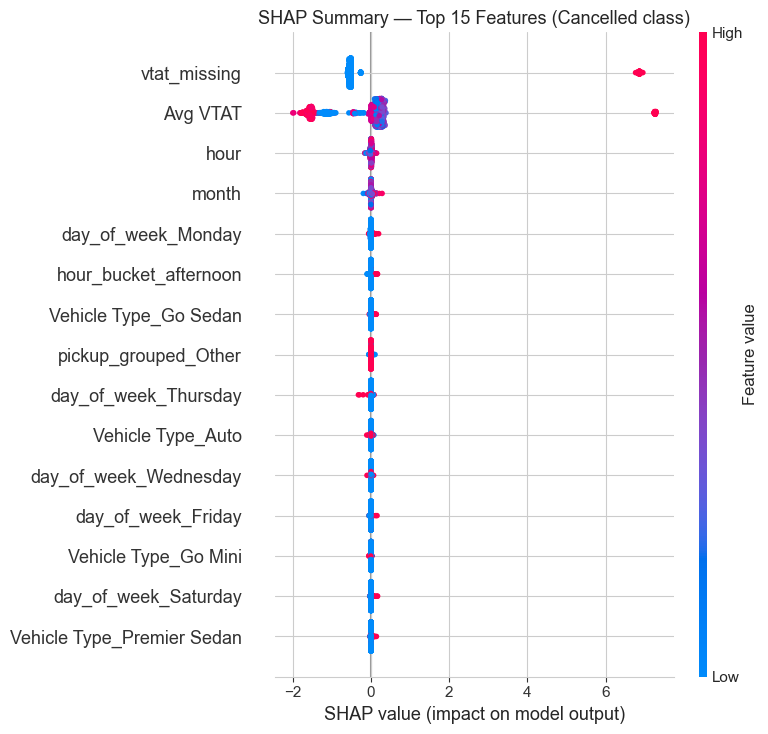

In [29]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap, max_display=15, show=False)
plt.title("SHAP Summary — Top 15 Features (Cancelled class)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.4 Mean |SHAP| feature importance

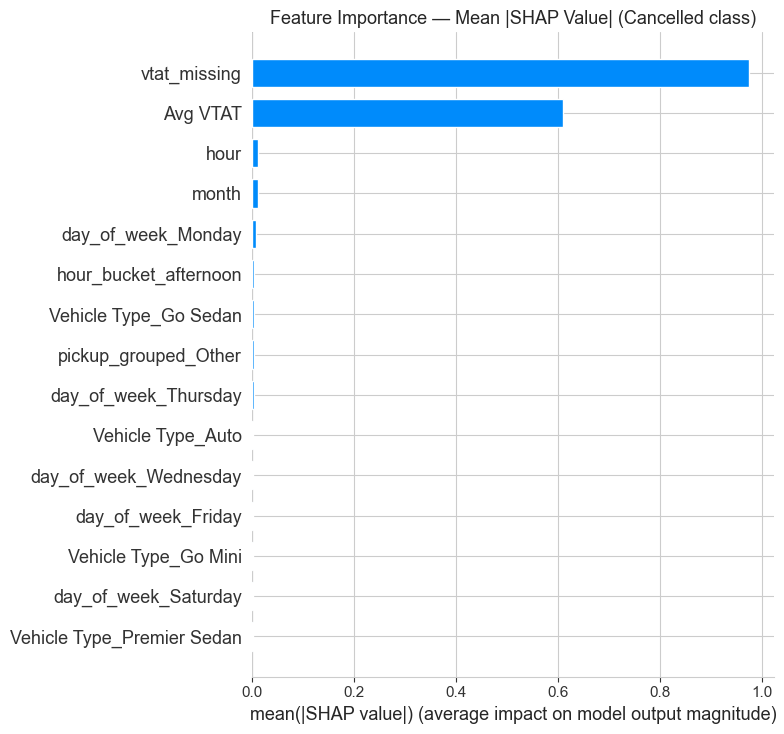

In [30]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_shap, plot_type="bar", max_display=15, show=False)
plt.title("Feature Importance — Mean |SHAP Value| (Cancelled class)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.5 Business interpretation

**Top drivers of cancellation (update rankings after running):**

1. **`Avg VTAT`** — longer driver assignment time directly raises cancellation
   risk. This is the primary actionable lever: bookings where VTAT is climbing
   should trigger immediate re-dispatch or driver incentives.

2. **`vtat_missing`** — when VTAT is absent entirely (No Driver Found), the
   booking was effectively already lost before it started. Real-time detection
   of zero driver availability should trigger immediate demand-supply rebalancing.

3. **`hour_bucket` / `hour`** — time-of-day signal captures driver supply
   scarcity patterns; late-night and early-morning slots show elevated risk.

4. **`Vehicle Type`** — certain vehicle categories (e.g. premium tiers) may
   show higher cancellation rates due to lower driver availability.

5. **`pickup_grouped` / `drop_grouped`** — specific corridors and locations
   with structurally low driver density appear as persistent risk factors.

**Key insight:** The two VTAT features dominate. This means the model is
largely a driver-supply detector — when the platform cannot match a driver
quickly, cancellation follows. Feature engineering in future iterations should
focus on richer supply-side signals: driver density radius, historical
availability by location-hour, and surge pricing status.

### 9.6 Individual prediction explanations — waterfall plots

TRUE POSITIVE — model correctly predicted Cancelled for sample #0


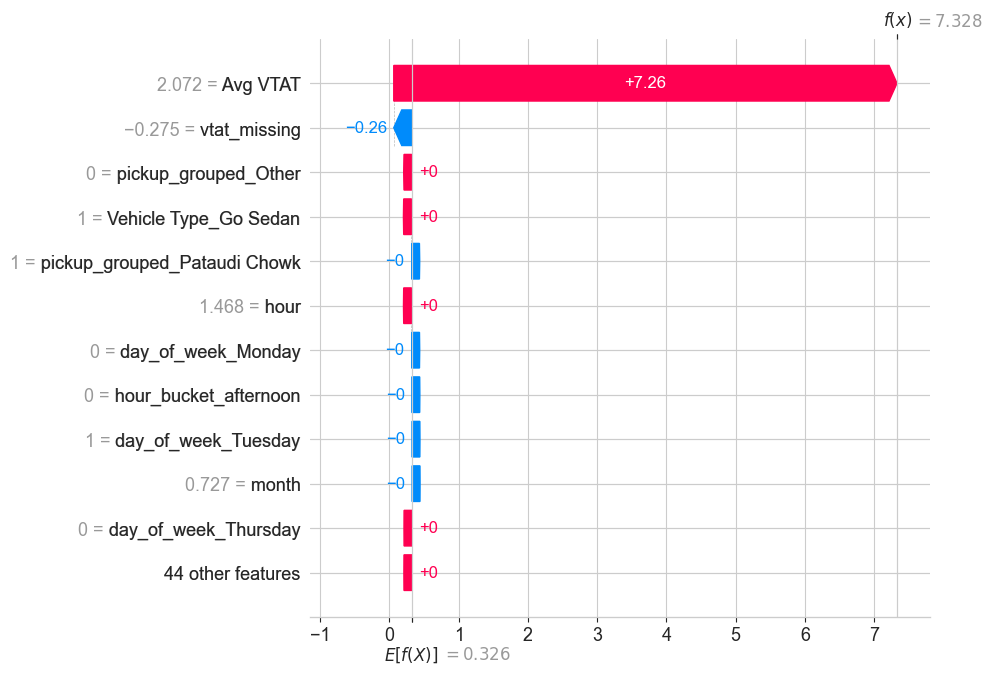

In [31]:
y_pred_shap = classifier_fitted.predict(X_shap)
y_test_shap = y_test.reset_index(drop=True).iloc[X_shap.index].reset_index(drop=True)

# True Positive: model correctly predicted Cancelled
tp_idx = np.where((y_pred_shap == 1) & (y_test_shap.values == 1))[0]
if len(tp_idx) > 0:
    idx = int(tp_idx[0])
    exp = shap.Explanation(
        values        = shap_vals[idx],
        base_values   = base_val,
        data          = X_shap.iloc[idx].values,
        feature_names = X_shap.columns.tolist()
    )
    print(f"TRUE POSITIVE — model correctly predicted Cancelled for sample #{idx}")
    shap.plots.waterfall(exp, max_display=12, show=True)
else:
    print("No true positives found in sample.")

TRUE NEGATIVE — model correctly predicted Completed for sample #1


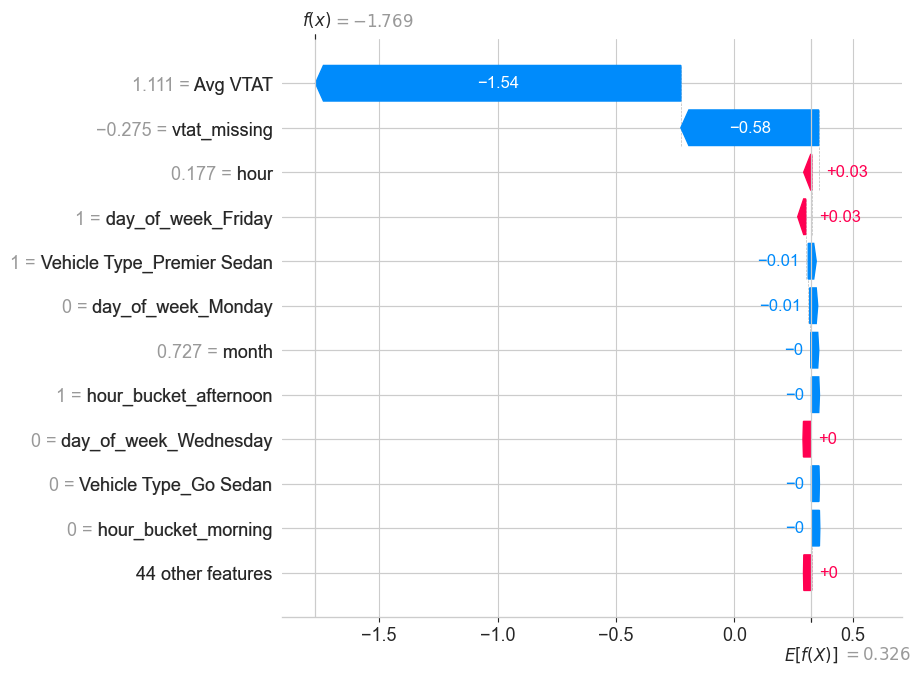

In [32]:
# True Negative: model correctly predicted Completed
tn_idx = np.where((y_pred_shap == 0) & (y_test_shap.values == 0))[0]
if len(tn_idx) > 0:
    idx2 = int(tn_idx[0])
    exp2 = shap.Explanation(
        values        = shap_vals[idx2],
        base_values   = base_val,
        data          = X_shap.iloc[idx2].values,
        feature_names = X_shap.columns.tolist()
    )
    print(f"TRUE NEGATIVE — model correctly predicted Completed for sample #{idx2}")
    shap.plots.waterfall(exp2, max_display=12, show=True)
else:
    print("No true negatives found in sample.")

## 10. MLflow Experiment Tracking & Model Serialization

MLflow provides reproducibility and auditability for every training run — parameters, metrics, and the trained model are all logged automatically.
This section covers three things required by the project guidelines:

1. **Experiment tracking** — log all three model runs with parameters and metrics
2. **Model serialization** — save the best pipeline as a single `.pkl` file
3. **Validation gate** — automated checks confirming the model meets minimum production standards before it could be deployed

### 10.1 Install and configure MLflow

In [33]:
!pip install -q mlflow

import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
import joblib
import time

# Store experiments locally (in Colab runtime)
mlflow.set_tracking_uri("mlruns")
EXPERIMENT_NAME = "uber-cancellation-prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

2026/04/15 12:19:54 INFO mlflow.tracking.fluent: Experiment with name 'uber-cancellation-prediction' does not exist. Creating a new experiment.


MLflow tracking URI: mlruns
Experiment: uber-cancellation-prediction


### 10.2 Log all three model runs

We re-train each model inside an `mlflow.start_run()` context so every parameter, metric, and the serialized pipeline are captured in one place. This mirrors the Week 8 demo pattern exactly.

In [34]:
model_configs = {
    "logistic-regression": {
        "model": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        "params": {
            "model_type":   "LogisticRegression",
            "max_iter":     1000,
            "class_weight": "balanced",
            "penalty":      "l2",
        }
    },
    "random-forest": {
        "model": RandomForestClassifier(
            n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        "params": {
            "model_type":   "RandomForest",
            "n_estimators": 100,
            "class_weight": "balanced",
        }
    },
    "gradient-boosting": {
        "model": HistGradientBoostingClassifier(
            max_iter=200, class_weight="balanced", random_state=42
        ),
        "params": {
            "model_type":   "HistGradientBoosting",
            "max_iter":     200,
            "class_weight": "balanced",
        }
    },
}

run_ids = {}

for run_name, config in model_configs.items():
    with mlflow.start_run(run_name=run_name) as run:

        pipe_m = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier",   config["model"])
        ])

        for k, v in config["params"].items():
            mlflow.log_param(k, v)
        mlflow.log_param("n_numeric_features",     len(NUMERIC_FEATURES))
        mlflow.log_param("n_categorical_features", len(CATEGORICAL_FEATURES))
        mlflow.log_param("train_size",             len(X_train))
        mlflow.log_param("test_size",              len(X_test))
        mlflow.log_param("random_state",           42)

        t0 = time.time()
        pipe_m.fit(X_train, y_train)
        training_time = time.time() - t0

        y_pred = pipe_m.predict(X_test)
        y_prob = pipe_m.predict_proba(X_test)[:, 1]

        metrics = {
            "roc_auc":              round(roc_auc_score(y_test, y_prob),      4),
            "recall_cancelled":     round(recall_score(y_test, y_pred),       4),
            "precision_cancelled":  round(precision_score(y_test, y_pred),    4),
            "f1_cancelled":         round(f1_score(y_test, y_pred),           4),
            "accuracy":             round(pipe_m.score(X_test, y_test),       4),
            "training_time_s":      round(training_time,                      2),
        }

        for k, v in metrics.items():
            mlflow.log_metric(k, v)

        mlflow.sklearn.log_model(pipe_m, "model")
        run_ids[run_name] = run.info.run_id

        print(f"{'='*55}")
        print(f"Run: {run_name}")
        for k, v in metrics.items():
            print(f"  {k:<28} {v}")
        print(f"  Run ID: {run.info.run_id[:8]}...")

print(f"\nAll runs logged to experiment: '{EXPERIMENT_NAME}'")

2026/04/15 12:19:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 12:19:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run: logistic-regression
  roc_auc                      0.6092
  recall_cancelled             0.1834
  precision_cancelled          0.9976
  f1_cancelled                 0.3099
  accuracy                     0.6895
  training_time_s              0.71
  Run ID: 34496f30...


2026/04/15 12:20:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 12:20:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run: random-forest
  roc_auc                      0.6871
  recall_cancelled             0.4482
  precision_cancelled          0.5768
  f1_cancelled                 0.5044
  accuracy                     0.6653
  training_time_s              4.77
  Run ID: 11b99854...


2026/04/15 12:20:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 12:20:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run: gradient-boosting
  roc_auc                      0.7248
  recall_cancelled             0.6655
  precision_cancelled          0.5156
  f1_cancelled                 0.581
  accuracy                     0.6353
  training_time_s              1.08
  Run ID: 978b5ff9...

All runs logged to experiment: 'uber-cancellation-prediction'


### 10.3 Query MLflow — experiment leaderboard

In [35]:
client     = MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
runs       = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.roc_auc DESC"]
)

leaderboard = []
for run in runs:
    leaderboard.append({
        "Run":            run.info.run_name,
        "Model":          run.data.params.get("model_type", ""),
        "ROC-AUC":        float(run.data.metrics.get("roc_auc", 0)),
        "Recall":         float(run.data.metrics.get("recall_cancelled", 0)),
        "Precision":      float(run.data.metrics.get("precision_cancelled", 0)),
        "F1":             float(run.data.metrics.get("f1_cancelled", 0)),
        "Train time (s)": float(run.data.metrics.get("training_time_s", 0)),
        "Run ID":         run.info.run_id[:8] + "...",
    })

lb_df = pd.DataFrame(leaderboard)
print("=" * 80)
print("EXPERIMENT LEADERBOARD (sorted by ROC-AUC)")
print("=" * 80)
print(lb_df.to_string(index=False))

EXPERIMENT LEADERBOARD (sorted by ROC-AUC)
                Run                Model  ROC-AUC  Recall  Precision     F1  Train time (s)      Run ID
  gradient-boosting HistGradientBoosting   0.7248  0.6655     0.5156 0.5810            1.08 978b5ff9...
      random-forest         RandomForest   0.6871  0.4482     0.5768 0.5044            4.77 11b99854...
logistic-regression   LogisticRegression   0.6092  0.1834     0.9976 0.3099            0.71 34496f30...


### 10.4 Serialize the best pipeline

We save the **full pipeline** — preprocessor and classifier together — as a single `.pkl` file using `joblib`. At serving time the pipeline accepts raw input directly with no separate preprocessing step, eliminating train-serve skew entirely.

In [36]:
# Reload best pipeline from MLflow to confirm logged model is identical
best_run_name = lb_df.iloc[0]["Run"]
best_run_id   = run_ids[best_run_name]

loaded_pipeline = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")

loaded_auc   = roc_auc_score(y_test, loaded_pipeline.predict_proba(X_test)[:, 1])
original_auc = lb_df.iloc[0]["ROC-AUC"]

print(f"Best run:             {best_run_name}")
print(f"Original ROC-AUC:     {original_auc:.4f}")
print(f"Loaded model ROC-AUC: {loaded_auc:.4f}")
print(f"Exact match:          {abs(loaded_auc - original_auc) < 0.0001}")
print(f"\nPipeline steps: {[s[0] for s in loaded_pipeline.steps]}")

# Save to disk
MODEL_PATH = os.path.join(MODELS_DIR, "best_pipeline.pkl")
joblib.dump(loaded_pipeline, MODEL_PATH)
print(f"\nSaved to {MODEL_PATH} ({os.path.getsize(MODEL_PATH) / 1024:.1f} KB)")

# Round-trip check: load from disk and predict on raw data
pipeline_from_disk = joblib.load(MODEL_PATH)
sample_pred  = pipeline_from_disk.predict(X_test.iloc[:3])
sample_proba = pipeline_from_disk.predict_proba(X_test.iloc[:3])[:, 1]

print(f"\nSample predictions on raw data (no preprocessing needed):")
print(f"  Labels:        {sample_pred}")
print(f"  Probabilities: {sample_proba.round(3)}")

Best run:             gradient-boosting
Original ROC-AUC:     0.7248
Loaded model ROC-AUC: 0.7248
Exact match:          True

Pipeline steps: ['preprocessor', 'classifier']

Saved to /Users/margarida/Documents/Fairfield University/01. MSBA/02. Spring 26/DATA 6545/Final Project/uber-cancellation-prediction/models/best_pipeline.pkl (247.6 KB)

Sample predictions on raw data (no preprocessing needed):
  Labels:        [1 1 1]
  Probabilities: [0.512 0.537 0.999]


### 10.5 Automated model validation gate

Before a model can be considered deployment-ready, it must pass a set of automated checks. Thresholds are set relative to our problem: ROC-AUC >= 0.65 (meaningful improvement over random for a hard problem with only booking-time features), Recall >= 0.50 (must catch at least half of cancellations to be operationally useful), plus standard sanity checks on prediction validity and latency.

In [37]:
def validate_model(model, X_test, y_test,
                   min_auc=0.65, min_recall=0.50, max_latency_ms=200,
                   model_name="model"):
    """Automated validation gate for the cancellation prediction model."""
    results = {}
    all_passed = True

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    print(f"\n{'='*58}")
    print(f"MODEL VALIDATION REPORT: {model_name}")
    print(f"{'='*58}")

    checks = [
        ("ROC-AUC",
         roc_auc_score(y_test, y_prob) >= min_auc,
         f"{roc_auc_score(y_test, y_prob):.4f}  (threshold >= {min_auc})"),

        ("Recall (Cancelled)",
         recall_score(y_test, y_pred) >= min_recall,
         f"{recall_score(y_test, y_pred):.4f}  (threshold >= {min_recall})"),

        ("No NaN predictions",
         not np.any(np.isnan(y_prob)),
         f"NaN count: {np.sum(np.isnan(y_prob))}"),

        ("Probs in [0, 1]",
         np.all((y_prob >= 0) & (y_prob <= 1)),
         f"Range: [{y_prob.min():.4f}, {y_prob.max():.4f}]"),

        ("Not predicting constant",
         np.std(y_prob) > 0.01,
         f"Std: {np.std(y_prob):.4f}"),
    ]

    # Latency check
    t0 = time.time()
    for _ in range(100):
        model.predict(X_test.iloc[[0]])
    avg_ms = (time.time() - t0) / 100 * 1000
    checks.append((
        "Latency",
        avg_ms < max_latency_ms,
        f"{avg_ms:.1f}ms  (threshold < {max_latency_ms}ms)"
    ))

    for name, passed, detail in checks:
        status = "PASS" if passed else "FAIL"
        print(f"  {status}  {name:<26} {detail}")
        results[name] = passed
        if not passed:
            all_passed = False

    print(f"{'='*58}")
    if all_passed:
        print("  VERDICT: ALL CHECKS PASSED -- model approved")
    else:
        failed = [k for k, v in results.items() if not v]
        print(f"  VERDICT: FAILED -- {', '.join(failed)}")
    print(f"{'='*58}")
    return all_passed


validate_model(
    pipeline_from_disk, X_test, y_test,
    model_name=f"Best pipeline ({best_run_name})"
)


MODEL VALIDATION REPORT: Best pipeline (gradient-boosting)
  PASS  ROC-AUC                    0.7248  (threshold >= 0.65)
  PASS  Recall (Cancelled)         0.6655  (threshold >= 0.5)
  PASS  No NaN predictions         NaN count: 0
  PASS  Probs in [0, 1]            Range: [0.0594, 0.9993]
  PASS  Not predicting constant    Std: 0.2187
  PASS  Latency                    5.6ms  (threshold < 200ms)
  VERDICT: ALL CHECKS PASSED -- model approved


True